Copyright Matlantis Corp. as contributors to Matlantis contrib project

# Deca-alanine α helix構造の平衡化

このノートブックではPFPを用いた分子動力学シミュレーションを実行して、[モデリング](./01_modeling_peptide_ja.ipynb)で作成したDeca-alanineのαヘリックス構造を緩和させます。

このNotebookで実施する主な工程は以下のとおりです:
1.  Step1: 環境設定: シミュレーションに必要なライブラリ (ASE, PFP) を読み込みます。
2.  Step2: 構造の読み込み: モデリングの工程で作成したPDBファイルを読み込みます。
3.  Step3: MDの実行: 温度300Kで短いシミュレーション(10ps)を行い、構造を緩和させます。

## Step1: ライブラリのインポート、PFPの設定

In [ ]:
import os
import matplotlib.pyplot as plt

# ASE (Atomic Simulation Environment)
from ase import units
from ase.io import read, write
from ase.io.proteindatabank import read_proteindatabank
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary

# PFP (Matlantis)
from pfp_api_client.pfp.calculators.ase_calculator import ASECalculator
from pfp_api_client.pfp.estimator import Estimator

# Calculatorの設定
calc_mode = "R2SCAN_PLUS_D3"
method_type = "PFVM_D3_PFVM"
model_version = "v8.0.0"

estimator = Estimator(calc_mode=calc_mode, method_type=method_type, model_version=model_version)
calculator = ASECalculator(estimator)

## Step2: 構造の読み込み

[モデリング行程]('./01_modeling_by_tleap_ja.ipynb')で作成したPDBファイル（`deca_alanine_helix.pdb`）を読み込みます。
もしこの工程をスキップしている場合は、`assets`フォルダに配置しているデータを使用します。

In [2]:
# インプットファイル
if os.path.exists(f"./output/01_modeling/deca_alanine_helix.pdb"): # Modelingを実施している場合
    inp_pdb = f"./output/01_modeling/deca_alanine_helix.pdb"
else:
    inp_pdb = f"./assets/02_equilibrium_nvt_md/deca_alanine_helix.pdb"

# アウトプットディレクトリ
out_dir = './output/02_equilibrium_nvt_md'
os.makedirs(out_dir, exist_ok=True)

In [3]:
# PDBを読み込む
atoms = read_proteindatabank(inp_pdb)
atoms

Atoms(symbols='C33H57N11O11', pbc=False, atomtypes=..., bfactor=..., occupancy=..., residuenames=..., residuenumbers=...)

## Step3: MDシミュレーションの実行

以下の条件で、構造緩和のための分子動力学シミュレーションを実行します。
* **アンサンブル:** NVT (粒子数、体積、温度一定)
* **温度制御:** Langevin thermostat (T = 300 K)
* **時間刻み:** dt = 1.0 fs
* **ステップ数:** 10,000 steps (10 ps)

In [4]:
# ------------------------------------------------------------
# Molecular Dynamics Parameters
# ------------------------------------------------------------
timestep    = 1.0 * units.fs
temperature = 300.0   # Kelvin
total_steps = 10_000  # 10 ps
friction    = 0.002 / units.fs # 摩擦係数

# 1. Calculatorをatomsにセット
atoms.calc = calculator

# 2. 初期速度の設定
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature, force_temp=True)
Stationary(atoms)  # 重心の並進運動をゼロにする

# 3. 温度制御・Integratorの設定
dyn = Langevin(atoms,
               timestep,
               temperature_K=temperature,
               friction=friction,
               trajectory=f'{out_dir}/md-dyn.traj',
               logfile=f'{out_dir}/md-dyn.log',
               loginterval=100)

# 4. シミュレーションの実行
print(f"Starting MD simulation for {total_steps} steps...")
dyn.run(total_steps)
print("MD simulation finished.")

# 5. 最終構造の保存
write(f'{out_dir}/deca_alanine_helix_eq.xyz', atoms)
write(f'{out_dir}/deca_alanine_helix_eq.pdb', atoms)
print(f"Files saved in {out_dir}")

Starting MD simulation for 10000 steps...
MD simulation finished.
Files saved in ./output/02_equilibrium_nvt_md


## Step 4: 緩和の確認（エネルギープロット）

構造が緩和したかを見るために、ポテンシャルエネルギーの変化を見て確認しましょう。
ステップが進むにつれて構造がリラックスし、エネルギーの値が安定していく様子が見えます。

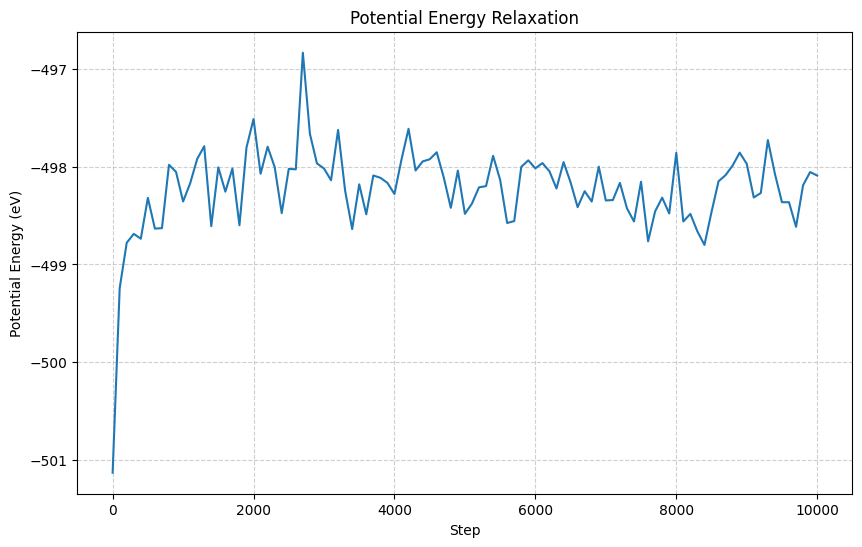

Initial Energy: -501.13 eV
Final Energy:   -498.09 eV


In [5]:
# 保存されたトラジェクトリファイルを読み込む
traj = read(f'output/02_equilibrium_nvt_md/md-dyn.traj', index=':')

# 各フレームのポテンシャルエネルギーを取り出す
pot_energies = [image.get_potential_energy() for image in traj]
steps = range(0, len(pot_energies) * 100, 100) # loginterval=100なので100倍する

# グラフのプロット
plt.figure(figsize=(10, 6))
plt.plot(steps, pot_energies)
plt.title("Potential Energy Relaxation")
plt.xlabel("Step")
plt.ylabel("Potential Energy (eV)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Initial Energy: {pot_energies[0]:.2f} eV")
print(f"Final Energy:   {pot_energies[-1]:.2f} eV")

## Next Step:

分子動力学シミュレーションを行うことで、モデリングで歪んだ構造を自然な構造へと緩和することができました。
次の[03_steered_md](03_steered_md_ja.ipynb) では、緩和した構造を両端を徐々に引っ張るシミュレーション（Steered MD）を行い、アンブレラサンプリングの各ウインドウの初期構造を作成していきます。